✅ Extracted 0 letters


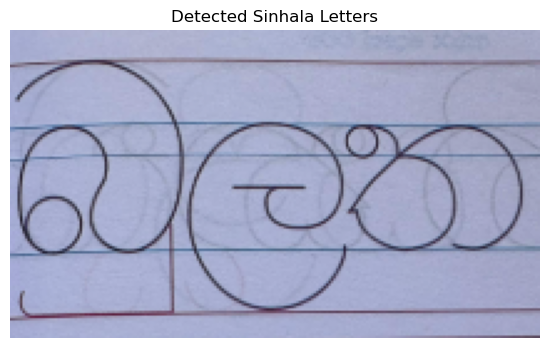

In [5]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt

# -------------------------------
# CONFIG
# -------------------------------
IMAGE_PATH = "idk1.png"
OUTPUT_DIR = "segmented_letters"
MIN_AREA = 800      # adjust if needed
PADDING = 5         # padding around letters

os.makedirs(OUTPUT_DIR, exist_ok=True)

# -------------------------------
# 1. LOAD IMAGE
# -------------------------------
img = cv2.imread(IMAGE_PATH)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# -------------------------------
# 2. BINARIZATION
# -------------------------------
thresh = cv2.adaptiveThreshold(
    gray,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV,
    21,
    10
)

# -------------------------------
# 3. REMOVE HORIZONTAL LINES
# -------------------------------
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (40, 1))
detected_lines = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=1)
clean = cv2.subtract(thresh, detected_lines)

# -------------------------------
# 4. MORPHOLOGICAL CLEANUP
# -------------------------------
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
clean = cv2.morphologyEx(clean, cv2.MORPH_CLOSE, kernel, iterations=2)

# -------------------------------
# 5. CONNECTED COMPONENTS
# -------------------------------
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
    clean, connectivity=8
)

letter_count = 0
output_boxes = img.copy()

for i in range(1, num_labels):  # skip background
    x, y, w, h, area = stats[i]

    if area < MIN_AREA:
        continue

    # Add padding safely
    x1 = max(x - PADDING, 0)
    y1 = max(y - PADDING, 0)
    x2 = min(x + w + PADDING, img.shape[1])
    y2 = min(y + h + PADDING, img.shape[0])

    letter = clean[y1:y2, x1:x2]
    letter_resized = cv2.resize(letter, (128, 128))

    cv2.imwrite(
        os.path.join(OUTPUT_DIR, f"letter_{letter_count}.png"),
        letter_resized
    )

    cv2.rectangle(output_boxes, (x1, y1), (x2, y2), (0, 255, 0), 2)
    letter_count += 1

print(f"✅ Extracted {letter_count} letters")

# -------------------------------
# 6. DISPLAY RESULT
# -------------------------------
plt.figure(figsize=(10, 4))
plt.imshow(cv2.cvtColor(output_boxes, cv2.COLOR_BGR2RGB))
plt.title("Detected Sinhala Letters")
plt.axis("off")
plt.show()
